<a href="https://colab.research.google.com/github/BahruzHuseynov/Portfolio/blob/main/Individual_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

General things before checking my code:
- I didn't use any website source and any copy from other place, all codes here are from my previous experience and work.
- I used Google Colab, as it supports additional GPU even TPU computational power which does fast matrix calculations at the back side of the deep learning models in training session.
- In order to download dataset to Google Colab, I used my kaggle account and via kaggle.json Google Colab connected to kaggle. Then by the name of the data folder in kaggle, I used it.
- I just used 1400 images from training images in website (1000 for training, 200 for validation and 200 for testing)
- Custom Dataset has been created and before training and testing, they have been added to DataLoaders with various batch sizes.
- Rather than using ImageDataGenerator, I just used another imaginary data generation way which is Data Augmentation in which the model sees various versions of the same image in the training phase.
- I built just a little bit random model as a BaseLine model. Just applied convolution, activation function for non-linearity (RELU), average pooling and so on in the baseline model.
- Second model is entire ResNet architecture that I previously built and even used it in my university project. You can find it in my github portfolio (https://github.com/BahruzHuseynov/Portfolio/). File name is 1_DND_Assignment_1_23_24_2.ipynb
- Finally, I just used VGG19 and ResNet-50 pre-trained models as a feature extractor and changed the classifier layers. SSD is mainly used for the object detection, maybe to capture direct image and then give it to the model can be a perfect choice, but by using pre-trained model, it is also possible to get a high accuracy.
- Final conclusions are at the end of the notebook.

<br>

File link: https://github.com/BahruzHuseynov/Portfolio/blob/main/Individual_Task.ipynb

## Import Libraries

I'll complete the task in PyTorch, but I also know TensorFlow and with a little bit search I could complete it with TensorFlow too.

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

import torch
from torch import nn, optim
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader

In [ ]:
!pip install kaggle

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"hbahruz","key":"44ffa2fb7937a90950ec027d3565ed14"}'}

In [ ]:
!mkdir ~/.kaggle
!mv kaggle.json ~/.kaggle/

In [ ]:
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle competitions download -c dogs-vs-cats

 99% 807M/812M [00:17<00:00, 34.6MB/s]
100% 812M/812M [00:18<00:00, 46.7MB/s]


In [ ]:
!unzip dogs-vs-cats.zip

Archive:  dogs-vs-cats.zip
  inflating: sampleSubmission.csv    
  inflating: test1.zip               
  inflating: train.zip               


In [ ]:
!unzip train.zip

Streaming output truncated to the last 5000 lines.
  inflating: train/dog.5499.jpg      
  inflating: train/dog.55.jpg        
  inflating: train/dog.550.jpg       
  inflating: train/dog.5500.jpg      
  inflating: train/dog.5501.jpg      
  inflating: train/dog.5502.jpg      
  inflating: train/dog.5503.jpg      
  inflating: train/dog.5504.jpg      
  inflating: train/dog.5505.jpg      
  inflating: train/dog.5506.jpg      
  inflating: train/dog.5507.jpg      
  inflating: train/dog.5508.jpg      
  inflating: train/dog.5509.jpg      
  inflating: train/dog.551.jpg       
  inflating: train/dog.5510.jpg      
  inflating: train/dog.5511.jpg      
  inflating: train/dog.5512.jpg      
  inflating: train/dog.5513.jpg      
  inflating: train/dog.5514.jpg      
  inflating: train/dog.5515.jpg      
  inflating: train/dog.5516.jpg      
  inflating: train/dog.5517.jpg      
  inflating: train/dog.5518.jpg      
  inflating: train/dog.5519.jpg      
  inflating: train/dog.552.jpg       

## Short Data Analysis

In [ ]:
print("Number of pictures: ", len(os.listdir('train')))

Number of pictures:  25000


In [ ]:
a = Image.open('train/'+random.choice(os.listdir('train')))
np.array(a).shape

(332, 500, 3)

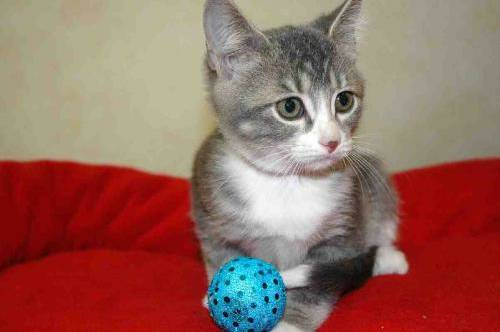

In [ ]:
a

After looking at some random pictures:
- The picture shapes differ from each other so they must be resized
- The images have been shot from close distance which is highly perfect in order to get a good performance
- Some pictures are blurry, but main parts to distinguish a cat from a dog is clear, such as whiskers, ears, eyes and so on.

## Dataset and DataLoader

I am planning to take 1000 training images, 200 validation images and 200 test images, randomly.

In [ ]:
cat_files = []
dog_files = []
data_dir = 'train'

for file in os.listdir(data_dir):
    if file.startswith('cat'):
        cat_files.append(os.path.join(data_dir, file))
    elif file.startswith('dog'):
        dog_files.append(os.path.join(data_dir, file))

random.shuffle(cat_files)
random.shuffle(dog_files)

In [ ]:
# In order to make the target balanced, I use same number of pictures
train_files = cat_files[:500] + dog_files[:500]
random.shuffle(train_files)

val_files = cat_files[500:600] + dog_files[500:600]
random.shuffle(val_files)

test_files = cat_files[600:700] + dog_files[600:700]
random.shuffle(test_files)

In [ ]:
train_files[0]

'train/dog.9750.jpg'

In [ ]:
class CatDogDataset(Dataset):
    def __init__(self, file_list, transform=None):
        self.file_list = file_list
        self.transform = transform

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        img_name = self.file_list[idx]
        image = Image.open(img_name)
        if self.transform:
            image = self.transform(image)

        label = 1 if 'dog' in img_name else 0
        return image, label

In [ ]:
# Data Augmentation
train_transform = transforms.Compose([
    transforms.RandomRotation(degrees=60),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

In [ ]:
train_dataset = CatDogDataset(train_files, transform=train_transform)
val_dataset = CatDogDataset(val_files, transform=transform)
test_dataset = CatDogDataset(test_files, transform=transform)

## Baseline Model Building

In the code snippet below, I just applied sequential model on one image to get output shape, as in the linear model the number of pixels will be needy after flattening the CNNs.

In [ ]:
tr = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

input_tensor = tr(a).unsqueeze(0)

mod = nn.Sequential(
    nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1),
    nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1),
    nn.AvgPool2d(kernel_size=3, stride = 1, padding = 0),
    nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, stride=1),
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.Conv2d(in_channels=32, out_channels=32, kernel_size=5, stride=1),
    nn.Conv2d(in_channels=32, out_channels=64, kernel_size=5, stride=2),
    nn.AvgPool2d(kernel_size=5, stride = 1, padding = 0),
    nn.Conv2d(in_channels=64, out_channels=64, kernel_size=5, stride=1),
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=1),
    nn.Conv2d(in_channels=64, out_channels=32, kernel_size=3, stride=1),
)

output_tensor = mod(input_tensor)
output_tensor.shape

torch.Size([1, 32, 92, 92])

In [ ]:
# Just used anything (Convolution, Relu activation, Pooling) to build a custom model
class BaseLineModel(nn.Module):
    def __init__(self):
        super(BaseLineModel, self).__init__()
        self.seq = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1),
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1),
            nn.MaxPool2d(kernel_size=3, stride = 1, padding = 0),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, stride=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=5, stride=1),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=5, stride=2),
            nn.MaxPool2d(kernel_size=5, stride = 1, padding = 0),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=5, stride=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=1),
            nn.Conv2d(in_channels=64, out_channels=32, kernel_size=3, stride=1),
        )

        self.final = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32*92*92, 128),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        return self.final(self.seq(x))

## Training and Testing with BaseLine Model

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [ ]:
def model_training(model, optimizer, criterion, num_epochs, train_dataset, val_dataset, batch_size):
    train_loader = DataLoader(train_dataset, batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size, shuffle=False)

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        running_corrects = 0

        for batch, labels in train_loader:
            batch, labels = batch.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(batch)
            _, preds = torch.max(outputs, 1)

            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(train_dataset)
        epoch_acc = running_corrects.double() / len(train_dataset)
        print(f'Epoch {epoch+1}/{num_epochs} | Train loss: {epoch_loss:.4f} | Train accuracy: {epoch_acc:.4f}')

        model.eval()
        running_val_loss = 0.0
        running_val_corrects = 0

        for batch, labels in val_loader:
            with torch.no_grad():
                batch, labels = batch.to(device), labels.to(device)

                outputs = model(batch)
                val_loss = criterion(outputs, labels)
                running_val_loss += val_loss.item()
                _, val_preds = torch.max(outputs, 1)
                running_val_corrects += torch.sum(val_preds == labels.data)

        val_loss = running_val_loss / len(val_dataset)
        val_acc = running_val_corrects.double() / len(val_dataset)
        print(f'Epoch {epoch+1}/{num_epochs} | Validation loss: {val_loss:.4f} | Validation accuracy: {val_acc:.4f}')

    return model

In [ ]:
def model_testing(model, test_dataset, criterion, batch_size):
    test_loader = DataLoader(test_dataset, batch_size, shuffle=False)

    model.eval()
    test_running_loss = 0.0
    test_running_corrects = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch, labels in test_loader:
            batch, labels = batch.to(device), labels.to(device)
            outputs = model(batch)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            test_running_loss += loss.item()
            test_running_corrects += torch.sum(preds == labels.data)

    test_epoch_loss = test_running_loss / len(test_loader.dataset)
    test_epoch_acc = test_running_corrects.double() / len(test_loader.dataset)
    print(f'Test loss: {test_epoch_loss:.4f} | Test accuracy: {test_epoch_acc:.4f}')

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    print("Classification Report:")
    print(classification_report(all_labels, all_preds))
    print("Accuracy Score:", accuracy_score(all_labels, all_preds))
    return all_preds, all_labels

Training and Testing with
- Batch size: 8
- Optimizer: Stochastic Gradient Descent with Momentum
- Learning rate: 0.01
- Number of epochs: 8

In [ ]:
model = BaseLineModel()
model.to(device)

batch_size = 8
f_loss = nn.CrossEntropyLoss()
optimizer = optim.SGD(mod.parameters(), lr=0.01, momentum = 0.9)
mod = model_training(model, optimizer, f_loss, 8, train_dataset, val_dataset, batch_size)

Epoch 1/8 | Train loss: 0.0865 | Train accuracy: 0.5260
Epoch 1/8 | Validation loss: 0.0865 | Validation accuracy: 0.5150
Epoch 2/8 | Train loss: 0.0864 | Train accuracy: 0.5220
Epoch 2/8 | Validation loss: 0.0866 | Validation accuracy: 0.5150
Epoch 3/8 | Train loss: 0.0867 | Train accuracy: 0.5030
Epoch 3/8 | Validation loss: 0.0865 | Validation accuracy: 0.5100
Epoch 4/8 | Train loss: 0.0868 | Train accuracy: 0.5020
Epoch 4/8 | Validation loss: 0.0865 | Validation accuracy: 0.5050
Epoch 5/8 | Train loss: 0.0865 | Train accuracy: 0.5260
Epoch 5/8 | Validation loss: 0.0866 | Validation accuracy: 0.5200
Epoch 6/8 | Train loss: 0.0867 | Train accuracy: 0.5050
Epoch 6/8 | Validation loss: 0.0865 | Validation accuracy: 0.5100
Epoch 7/8 | Train loss: 0.0865 | Train accuracy: 0.5180
Epoch 7/8 | Validation loss: 0.0866 | Validation accuracy: 0.5100
Epoch 8/8 | Train loss: 0.0868 | Train accuracy: 0.4880
Epoch 8/8 | Validation loss: 0.0865 | Validation accuracy: 0.5150


In [ ]:
model_testing(mod, test_dataset, f_loss, batch_size)

Test loss: 0.0864 | Test accuracy: 0.5000
Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.63      0.56       100
           1       0.50      0.37      0.43       100

    accuracy                           0.50       200
   macro avg       0.50      0.50      0.49       200
weighted avg       0.50      0.50      0.49       200

Accuracy Score: 0.5


Generally, the results are not satisfactory, almost bad at classification.

Training and Testing with
- Batch size: 8
- Optimizer: Adam
- Learning rate: 0.01
- Number of epochs: 16

As the model is built from scratch it is impossible to learn data with 8 epochs and additionally, we change optimizer into sophisticated one.

In [ ]:
model = BaseLineModel()
model.to(device)

batch_size = 8
f_loss = nn.CrossEntropyLoss()
optimizer = optim.Adam(mod.parameters(), lr=0.01)
mod = model_training(model, optimizer, f_loss, 16, train_dataset, val_dataset, batch_size)

Epoch 1/16 | Train loss: 0.0871 | Train accuracy: 0.4740
Epoch 1/16 | Validation loss: 0.0873 | Validation accuracy: 0.4450
Epoch 2/16 | Train loss: 0.0870 | Train accuracy: 0.4760
Epoch 2/16 | Validation loss: 0.0873 | Validation accuracy: 0.4300
Epoch 3/16 | Train loss: 0.0868 | Train accuracy: 0.5030
Epoch 3/16 | Validation loss: 0.0873 | Validation accuracy: 0.4450
Epoch 4/16 | Train loss: 0.0870 | Train accuracy: 0.4900
Epoch 4/16 | Validation loss: 0.0873 | Validation accuracy: 0.4550
Epoch 5/16 | Train loss: 0.0872 | Train accuracy: 0.4480
Epoch 5/16 | Validation loss: 0.0873 | Validation accuracy: 0.4450
Epoch 6/16 | Train loss: 0.0870 | Train accuracy: 0.5010
Epoch 6/16 | Validation loss: 0.0873 | Validation accuracy: 0.4550
Epoch 7/16 | Train loss: 0.0869 | Train accuracy: 0.4870
Epoch 7/16 | Validation loss: 0.0873 | Validation accuracy: 0.4500
Epoch 8/16 | Train loss: 0.0870 | Train accuracy: 0.4750
Epoch 8/16 | Validation loss: 0.0873 | Validation accuracy: 0.4400
Epoch 9/

## Training and Testing perforamnce of ResNet built from scratch

So, we see that model is really strugling to learn (no overfitting but not a good accuracy). So, let's use more complex model. <br>

Now, I'll use ResNet-101 that I previously built and added to my github account (I also applied it on my university assignment). As, I built it beforehand, I'll just copy it.

In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, model_name, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        self.models = ["18", "34", "50", "101", "152"]
        assert model_name in self.models

        self.model_name = model_name
        self.stride = stride
        self.expansion = 4 if model_name in ["50", "101", "152"] else 1
        final_out = out_channels * self.expansion

        if self.model_name in ["18", "34"]:
            self.seq = nn.Sequential(
                # input, output, kernel, stride, padding
                nn.Conv2d(in_channels, out_channels, 3, stride, 1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(),
                nn.Dropout(0.1), # Additional Dropout
                nn.Conv2d(out_channels, out_channels, 3, 1, 1),
                nn.BatchNorm2d(out_channels)
            )

        else:
            self.seq = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride, 0),
                nn.BatchNorm2d(out_channels),
                nn.Conv2d(out_channels, out_channels, 3, 1, 1),
                nn.BatchNorm2d(out_channels),
                nn.Conv2d(out_channels, final_out, 1, 1, 0),
                nn.BatchNorm2d(final_out),
                nn.ReLU(),
                nn.Dropout(0.1) # Additional Dropout
            )

        self.shortcut = None
        if stride != 1 or in_channels != final_out:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, final_out, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(final_out)
            )


    def forward(self, x):
        residual = x

        out = self.seq(x)
        if self.shortcut is not None:
            out += self.shortcut(x)
        else:
            out += x
        return out

class ResNet(nn.Module):
    def __init__(self, Rblock, num_classes, model_name="18"):
        super(ResNet, self).__init__()
        self.models = ["18", "34", "50", "101", "152"]
        assert model_name in self.models

        self.model_name = model_name
        self.num_classes = num_classes
        self.Rblock = Rblock
        filters = [64, 128, 256, 512]
        self.num_blocks = {
            "18": [2, 2, 2, 2],
            "34": [3, 4, 6, 3],
            "50": [3, 4, 6, 3],
            "101": [3, 4, 23, 3],
            "152": [3, 8, 36, 3]
        }
        mod_block = self.num_blocks[model_name]

        self.initial = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2), # Additional Dropout
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        self.block1 = self.make_block(64, filters[0], mod_block[0], stride=1)
        self.block2 = self.make_block(filters[0] * Rblock(self.model_name, 64, filters[0]).expansion,
                                       filters[1], mod_block[1], stride=2)
        self.block3 = self.make_block(filters[1] * Rblock(self.model_name, filters[0], filters[1], 2).expansion,
                                       filters[2], mod_block[2], stride=2)
        self.block4 = self.make_block(filters[2] * Rblock(self.model_name, filters[1], filters[2], 2).expansion,
                                       filters[3], mod_block[3], stride=2)

        if model_name in ["18", "34"]:
            self.final = nn.Sequential(
                nn.AdaptiveAvgPool2d((1, 1)),
                nn.Flatten(),
                nn.Linear(filters[3], 500) # change
            )
        else:
            self.final = nn.Sequential(
                nn.AdaptiveAvgPool2d((1, 1)),
                nn.Flatten(),
                nn.Linear(filters[3] * 4, 500) # change
            )

        #additional layer
        self.before_pred = nn.Sequential(
            nn.Linear(500, 350),
            nn.Linear(350, 200)
        )
        self.fc_class = nn.Linear(in_features=200, out_features=self.num_classes)

    def make_block(self, in_channels, out_channels, num_blocks, stride=1):
        layers = []
        layers.append(self.Rblock(self.model_name, in_channels, out_channels, stride))
        for _ in range(1, num_blocks):
            layers.append(self.Rblock(self.model_name, out_channels * self.Rblock(self.model_name, in_channels, out_channels, stride).expansion, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.initial(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.final(x)
        x = self.before_pred(x)
        return self.fc_class(x)

Training and Testing with
- Batch size: 16
- Optimizer: Adam
- Learning rate: 0.01
- Number of epochs: 16

In [ ]:
model = ResNet(ResidualBlock, 2, "101").to(device)
f_loss = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)
batch_size = 16

In [ ]:
mod = model_training(model, optimizer, f_loss, 16, train_dataset, val_dataset, batch_size)

Epoch 1/16 | Train loss: 3.3234 | Train accuracy: 0.5050
Epoch 1/16 | Validation loss: 0.0552 | Validation accuracy: 0.5050
Epoch 2/16 | Train loss: 0.0538 | Train accuracy: 0.4710
Epoch 2/16 | Validation loss: 0.0452 | Validation accuracy: 0.4600
Epoch 3/16 | Train loss: 0.0440 | Train accuracy: 0.5280
Epoch 3/16 | Validation loss: 0.0450 | Validation accuracy: 0.4950
Epoch 4/16 | Train loss: 0.0439 | Train accuracy: 0.4910
Epoch 4/16 | Validation loss: 0.0450 | Validation accuracy: 0.5000
Epoch 5/16 | Train loss: 0.0438 | Train accuracy: 0.5270
Epoch 5/16 | Validation loss: 0.0446 | Validation accuracy: 0.5400
Epoch 6/16 | Train loss: 0.0439 | Train accuracy: 0.5370
Epoch 6/16 | Validation loss: 0.0449 | Validation accuracy: 0.5200
Epoch 7/16 | Train loss: 0.0441 | Train accuracy: 0.5330
Epoch 7/16 | Validation loss: 0.0447 | Validation accuracy: 0.5350
Epoch 8/16 | Train loss: 0.0441 | Train accuracy: 0.5170
Epoch 8/16 | Validation loss: 0.0448 | Validation accuracy: 0.5400
Epoch 9/

In [ ]:
model_testing(mod, test_dataset, f_loss, batch_size)

Test loss: 0.0454 | Test accuracy: 0.5200
Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.07      0.13       100
           1       0.51      0.97      0.67       100

    accuracy                           0.52       200
   macro avg       0.61      0.52      0.40       200
weighted avg       0.61      0.52      0.40       200

Accuracy Score: 0.52


0.02% improvement, almost no any rise, additionally, recall for the class 0 is terrible.

### Using pre-trained model as a feature extractor (Transfer Learning, without Fine Tuning)
- ResNet 50
- VGG 19

## VGG19

In [ ]:
mod_vgg19 = models.vgg19(pretrained=True)

In [ ]:
mod_vgg19

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padd

In [ ]:
# Freezing layers
for param in mod_vgg19.parameters():
    param.requires_grad = False

In [ ]:
classifier_final_layer = mod_vgg19.classifier[6].in_features
mod_vgg19.classifier[6] = nn.Linear(classifier_final_layer, 2)

In [ ]:
mod_vgg19.to(device)

batch_size = 16
f_loss = nn.CrossEntropyLoss()
optimizer = optim.SGD(mod_vgg19.parameters(), lr=0.01, momentum = 0.9)
mod = model_training(mod_vgg19, optimizer, f_loss, 8, train_dataset, val_dataset, batch_size)

Epoch 1/8 | Train loss: 0.0607 | Train accuracy: 0.8360
Epoch 1/8 | Validation loss: 0.0268 | Validation accuracy: 0.9300
Epoch 2/8 | Train loss: 0.0604 | Train accuracy: 0.8650
Epoch 2/8 | Validation loss: 0.0192 | Validation accuracy: 0.9450
Epoch 3/8 | Train loss: 0.0946 | Train accuracy: 0.8510
Epoch 3/8 | Validation loss: 0.0257 | Validation accuracy: 0.9450
Epoch 4/8 | Train loss: 0.0690 | Train accuracy: 0.8870
Epoch 4/8 | Validation loss: 0.0328 | Validation accuracy: 0.9450
Epoch 5/8 | Train loss: 0.0779 | Train accuracy: 0.8830
Epoch 5/8 | Validation loss: 0.0299 | Validation accuracy: 0.9450
Epoch 6/8 | Train loss: 0.0774 | Train accuracy: 0.8730
Epoch 6/8 | Validation loss: 0.0205 | Validation accuracy: 0.9750
Epoch 7/8 | Train loss: 0.0931 | Train accuracy: 0.8700
Epoch 7/8 | Validation loss: 0.0632 | Validation accuracy: 0.9150
Epoch 8/8 | Train loss: 0.0755 | Train accuracy: 0.8910
Epoch 8/8 | Validation loss: 0.0255 | Validation accuracy: 0.9500


In [ ]:
preds, actual = model_testing(mod, test_dataset, f_loss, batch_size)

Test loss: 0.0192 | Test accuracy: 0.9600
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       100
           1       0.96      0.96      0.96       100

    accuracy                           0.96       200
   macro avg       0.96      0.96      0.96       200
weighted avg       0.96      0.96      0.96       200

Accuracy Score: 0.96


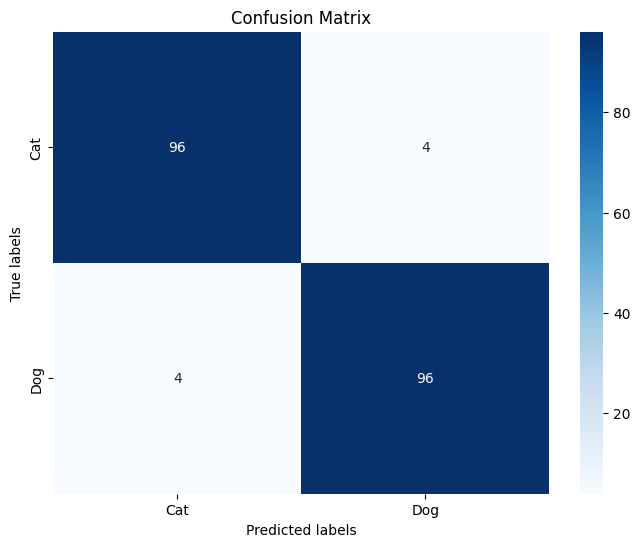

In [ ]:
cm = confusion_matrix(actual, preds)

class_labels = ['Cat', 'Dog']

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

## ResNet-50

In [ ]:
mod_resnet50 = models.resnet50(pretrained=True)

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:02<00:00, 38.3MB/s]


In [ ]:
mod_resnet50

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:
for param in mod_resnet50.parameters():
    param.requires_grad = False

fc = mod_resnet50.fc.in_features
mod_resnet50.fc = nn.Linear(fc, 2)

In [ ]:
mod_resnet50.to(device)

batch_size = 16
f_loss = nn.CrossEntropyLoss()
optimizer = optim.SGD(mod_resnet50.parameters(), lr=0.01, momentum = 0.9)
mod = model_training(mod_resnet50, optimizer, f_loss, 8, train_dataset, val_dataset, batch_size)

Epoch 1/8 | Train loss: 0.0203 | Train accuracy: 0.8820
Epoch 1/8 | Validation loss: 0.0140 | Validation accuracy: 0.9350
Epoch 2/8 | Train loss: 0.0339 | Train accuracy: 0.8840
Epoch 2/8 | Validation loss: 0.0280 | Validation accuracy: 0.9200
Epoch 3/8 | Train loss: 0.0183 | Train accuracy: 0.9270
Epoch 3/8 | Validation loss: 0.0060 | Validation accuracy: 0.9700
Epoch 4/8 | Train loss: 0.0169 | Train accuracy: 0.9350
Epoch 4/8 | Validation loss: 0.0087 | Validation accuracy: 0.9500
Epoch 5/8 | Train loss: 0.0172 | Train accuracy: 0.9200
Epoch 5/8 | Validation loss: 0.0041 | Validation accuracy: 0.9750
Epoch 6/8 | Train loss: 0.0132 | Train accuracy: 0.9340
Epoch 6/8 | Validation loss: 0.0065 | Validation accuracy: 0.9650
Epoch 7/8 | Train loss: 0.0150 | Train accuracy: 0.9340
Epoch 7/8 | Validation loss: 0.0020 | Validation accuracy: 0.9800
Epoch 8/8 | Train loss: 0.0168 | Train accuracy: 0.9300
Epoch 8/8 | Validation loss: 0.0099 | Validation accuracy: 0.9550


In [ ]:
preds, actual = model_testing(mod, test_dataset, f_loss, batch_size)

Test loss: 0.0047 | Test accuracy: 0.9750
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.97       100
           1       0.95      1.00      0.98       100

    accuracy                           0.97       200
   macro avg       0.98      0.97      0.97       200
weighted avg       0.98      0.97      0.97       200

Accuracy Score: 0.975


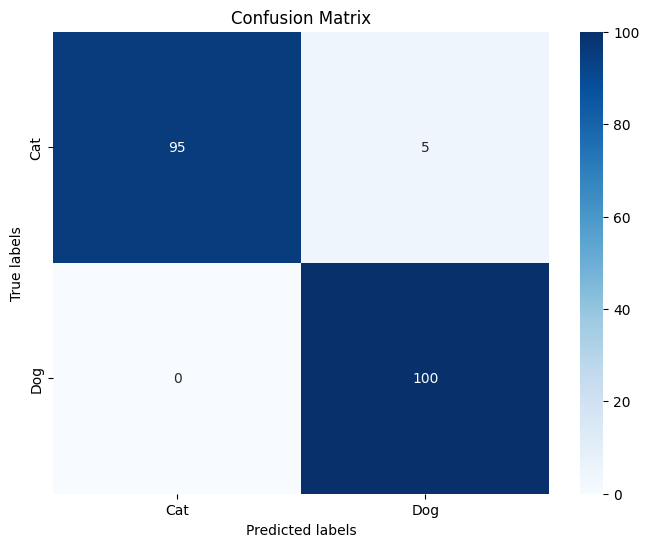

In [ ]:
cm = confusion_matrix(actual, preds)

class_labels = ['Cat', 'Dog']

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

## Final Conclusion

Base Line model - 50 % accuracy <br>
ResNet-101 from scratch - 50.2% accuracy <br>
I considered that, may be, a complex model can at least increase the accuracy approximately 5% but it just increased 0.2%. It is totally equal to no improvement. Additionally, considering that the models are executed from scratch, the number of epochs are less 8 or 16. Maybe 40,60 or 80 epochs could do a good job.

<br>
VGG 19 - Transfer learning - 95% accuracy <br>
ResNet 50 - Transfer Learning - 97.5% accuracy <br>
For pre-trained models. It occurred as I thought. VGG19 did a good job and more complex model, ResNet-50, captured more details. If I have enough time, I would apply Step Scheduler which is used to adjust learning rate after some epochs. By this way, I think I could get better result as my main learning rate was 0.01.